#**BT4012 Final Project**
Group 02:

*   Chen Yihao (A0252796N)
*   Diane Teo Min Xuan (A0259461X)
*   Parama Roy Poja (A0282313M)
*   Tan Si Rui (A0223701W)



## 0. Environment Set-up

### 0.1. Python imports

In [2]:
import cv2, os, random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from concurrent.futures import ProcessPoolExecutor, as_completed
from PIL import Image

from scipy.stats import kurtosis
from skimage.feature import local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models as keras_models
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence


import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as T

from tqdm import tqdm
import xgboost as xgb


In [3]:
# Reproducibility
RANDOM_SEED = 1500
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### 0.2. Loading the dataset
We load all images from the flat folder, keep only filenames with `original_` or `manipulated_` prefixes, and build a single DataFrame with full paths and labels.


#### GDrive

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
data_dir = '/content/drive/MyDrive/image_data_flatten'
df = pd.read_csv(os.path.join(data_dir, 'df_balanced.csv'))

df['path'] = df['path'].apply(lambda x: os.path.join(data_dir, x))

Sample files: ['original_sequences_actors_c23_27__podium_speech_happy_frame_04.jpg', 'original_sequences_actors_c23_12__kitchen_still_frame_05.jpg', 'original_sequences_actors_c23_19__secret_conversation_frame_05.jpg']
Total files found: 47169


#### Local

In [9]:
df = pd.read_csv('./data/df_balanced.csv')
df['path'] = df['path'].apply(lambda x: '../image_data_flatten/' + x) 

## 1. Exploratory Data Analysis

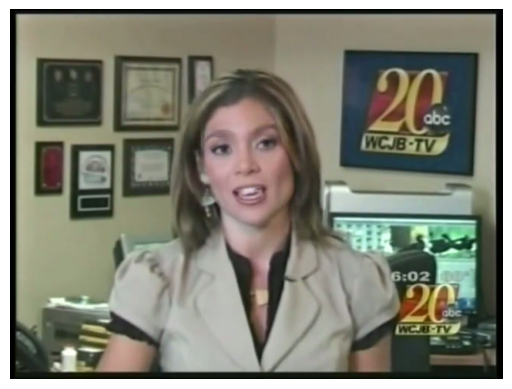

In [10]:
# test if the image can be loaded
test_image_path = df['path'].iloc[0]
img = Image.open(test_image_path)

plt.imshow(img)
plt.axis('off')
plt.show()


### 1.1. Is the dataset balanced?
We visualise the class distribution for original vs manipulated faces.

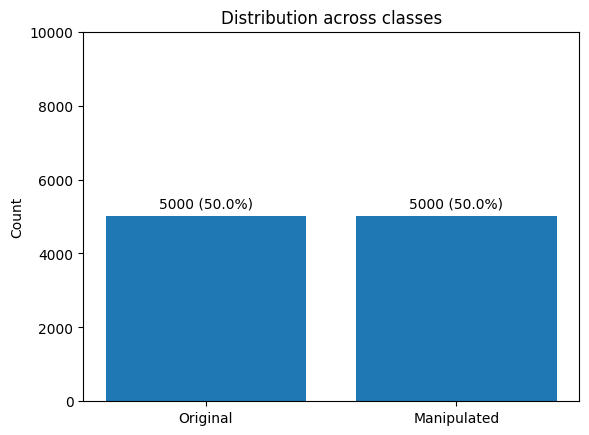

In [12]:
num_negatives = len(df[df['label'] == 0])
num_positives = len(df[df['label'] == 1])
total = num_negatives + num_positives

categories = ['Original', 'Manipulated']
counts = [num_negatives, num_positives]

# plot bar chart to view distribution of dataset
percentages = [count / total * 100 for count in counts]

fig, ax = plt.subplots()
bars = ax.bar(categories, counts)

# add labels (count + percentage) above each bar
for bar, count, pct in zip(bars, counts, percentages):
    ax.annotate(f'{count} ({pct:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center', va='bottom')

plt.title('Distribution across classes')
plt.ylabel('Count')
plt.ylim(0, 10000)
plt.show()

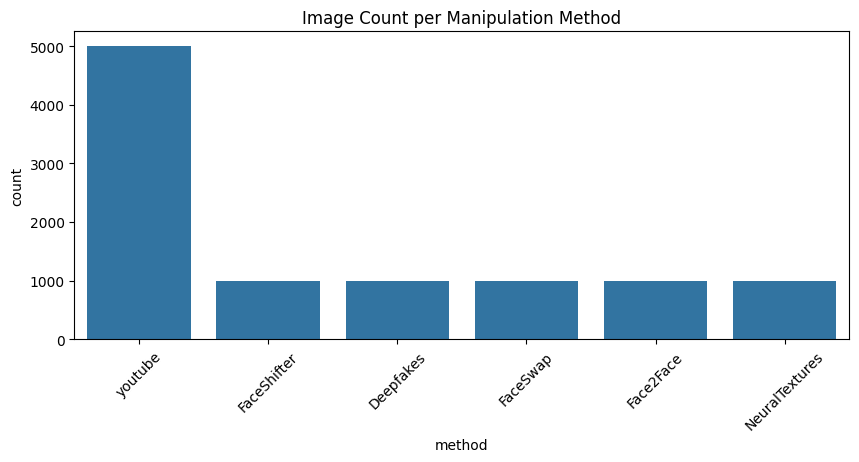

In [13]:
counts = df['method'].value_counts().reset_index()
counts.columns = ["method", "count"]

plt.figure(figsize=(10,4))
sns.barplot(data=counts, x="method", y="count")
plt.xticks(rotation=45)
plt.title("Image Count per Manipulation Method")
plt.show()


## 2. Feature Engineering

We build a **face-centric pipeline**:

1. Detect face using Haar cascade; fall back to central crop if detection fails.  
2. Resize to **299×299** and normalise to `[0,1]`.  
3. Extract **12 handcrafted forensic features** per image:

- HPF mean & variance (Laplacian)
- Edge density (Canny)
- Gradient energy (Sobel magnitude)
- LBP uniformity ratio
- DCT band energy ratios (Low, Mid, High)
- JPEG blockiness score
- Ring–centre sharpness, brightness, and chroma differences

### 2.1. Facial Detection

In [32]:
IMG_SIZE = (299, 299)


def detect_face_bbox(gray):
    """
    Detect face bounding box in a grayscale image using Haar cascade.
    Returns (x, y, w, h) or None if no face found.
    """

    # Haar cascade face detector
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )


    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(40, 40)
    )
    if len(faces) == 0:
        return None

    # pick the largest detected face
    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
    return x, y, w, h

def crop_to_face_or_center(img_bgr, center_ratio=0.6, expand_ratio=1.2):
    """
    Try to crop a face region. If no face is detected, fall back to a central crop.
    Returns BGR crop.
    """
    h, w, _ = img_bgr.shape
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    bbox = detect_face_bbox(gray)
    if bbox is not None:
        x, y, fw, fh = bbox
        # expand bbox a bit to include context
        cx = x + fw / 2
        cy = y + fh / 2
        size = int(max(fw, fh) * expand_ratio)
        x1 = int(max(cx - size / 2, 0))
        y1 = int(max(cy - size / 2, 0))
        x2 = int(min(cx + size / 2, w))
        y2 = int(min(cy + size / 2, h))
        face_crop = img_bgr[y1:y2, x1:x2]
        if face_crop.size > 0:
            return face_crop

    # fallback: central crop (approximate face region)
    cr = center_ratio
    r1 = int((1 - cr) / 2 * h)
    r2 = int((1 + cr) / 2 * h)
    c1 = int((1 - cr) / 2 * w)
    c2 = int((1 + cr) / 2 * w)
    return img_bgr[r1:r2, c1:c2]

### 2.2. RGB & Grayscale

In [33]:
def load_image_rgb(path, img_size=IMG_SIZE):
    """
    Load image, detect face, crop to face (or center), resize, and return RGB float32 in [0,1].
    """
    img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")

    face_bgr = crop_to_face_or_center(img_bgr)
    face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    face_rgb = cv2.resize(face_rgb, img_size, interpolation=cv2.INTER_AREA)
    face_rgb = face_rgb.astype(np.float32) / 255.0
    return face_rgb

def get_gray(img_rgb):
    """Convert RGB [0,1] float image to uint8 grayscale."""
    img_255 = (img_rgb * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_255, cv2.COLOR_RGB2GRAY)
    return gray

### 2.3. High-pass Residual (Laplacian), Gradient Energy and Edges

In [34]:
def hpf_features(gray):
    # laplacian high-pass
    lap = cv2.Laplacian(gray.astype(np.float32), cv2.CV_32F, ksize=3)
    hpf_mean = float(lap.mean())
    hpf_var  = float(lap.var())
    return hpf_mean, hpf_var

def edge_density_canny(gray):
    edges = cv2.Canny(gray, threshold1=100, threshold2=200)
    density = float((edges > 0).mean())
    return density

def gradient_energy(gray):
    gx = cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    energy = float(mag.mean())  # average gradient magnitude
    return energy

def compute_local_features(img_rgb):
    """
    Compute HPF mean/var, edge density, gradient energy on FACE RGB [0,1] image.
    """
    gray = get_gray(img_rgb)

    hpf_mean, hpf_var = hpf_features(gray)
    edge_dens = edge_density_canny(gray)
    grad_en   = gradient_energy(gray)

    # visualisation maps
    lap = cv2.Laplacian(gray.astype(np.float32), cv2.CV_32F, ksize=3)
    lap_vis = np.abs(lap)
    lap_vis = lap_vis / (lap_vis.max() + 1e-8)  # normalise 0–1 for display

    edges = cv2.Canny(gray, 100, 200)

    gx = cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    mag_vis = mag / (mag.max() + 1e-8)

    metrics = {
        "hpf_mean": hpf_mean,
        "hpf_var": hpf_var,
        "edge_density": edge_dens,
        "gradient_energy": grad_en,
    }
    visuals = {
        "gray": gray,
        "lap_vis": lap_vis,
        "edges": edges,
        "mag_vis": mag_vis,
    }
    return metrics, visuals

Original sample: original_sequences_youtube_c23_143_frame_03.jpg
Manipulated sample: manipulated_sequences_NeuralTextures_c23_637_427_frame_03.jpg


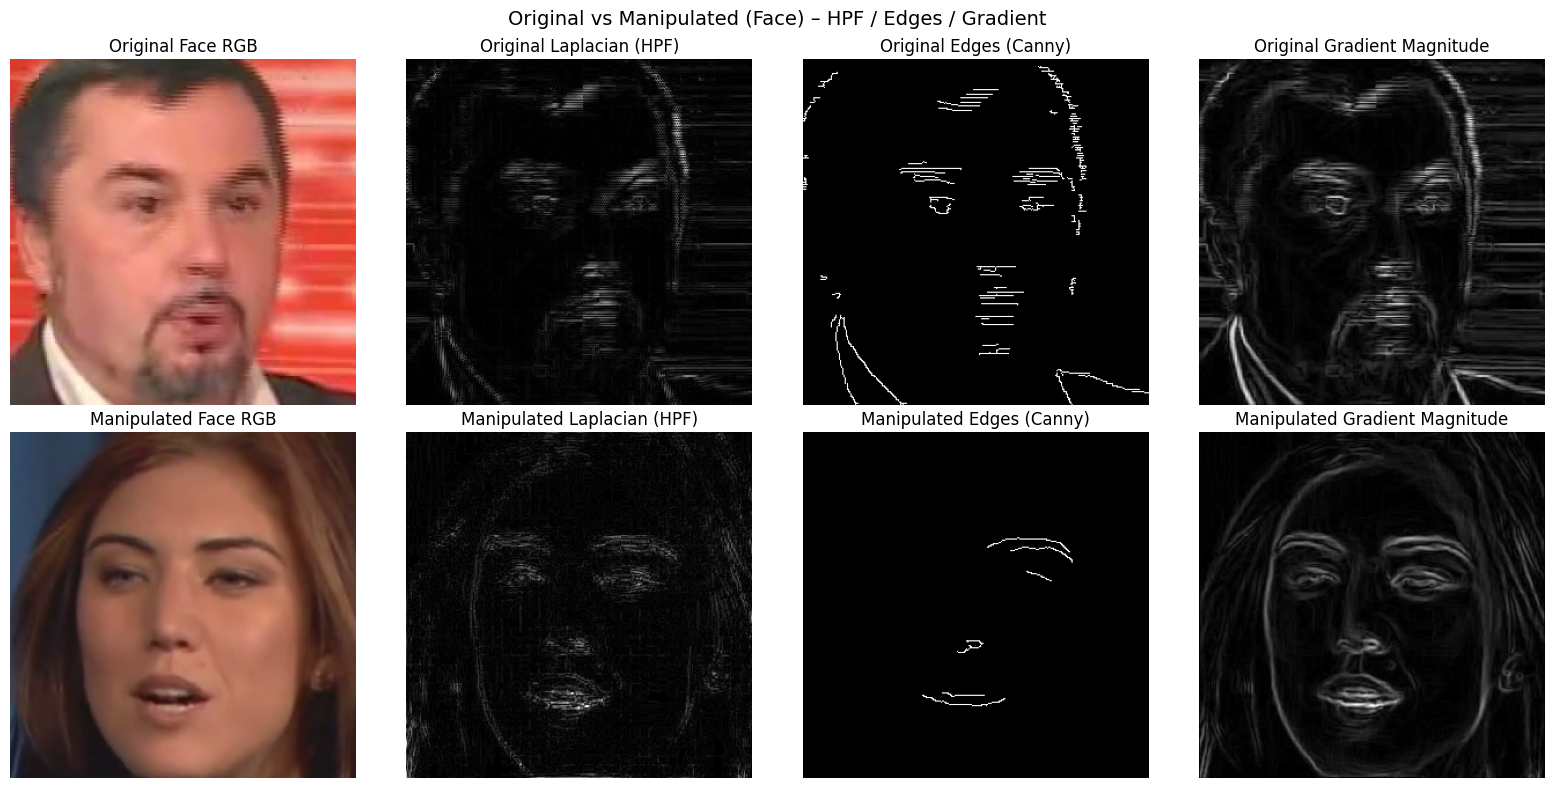

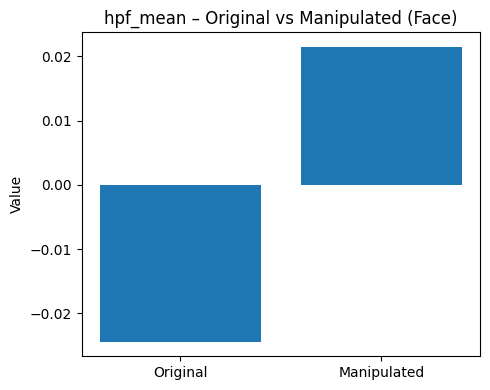

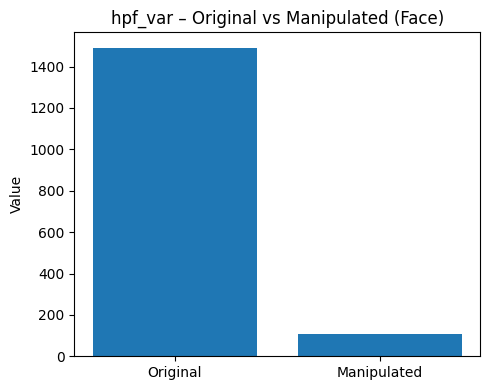

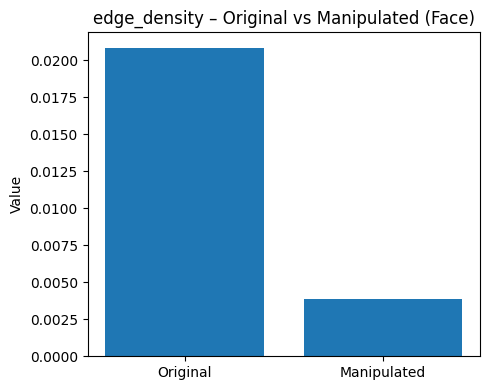

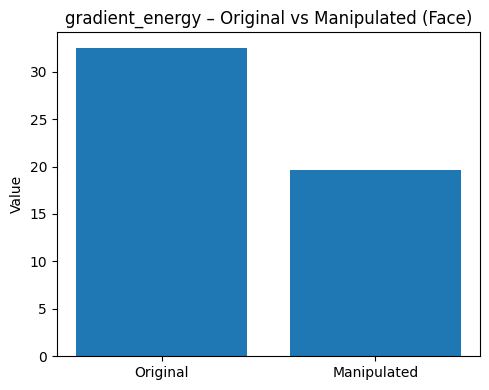

Original metrics: {'hpf_mean': -0.02438451535999775, 'hpf_var': 1491.134521484375, 'edge_density': 0.02086106419391282, 'gradient_energy': 32.51455307006836}
Manipulated metrics: {'hpf_mean': 0.02143152803182602, 'hpf_var': 105.93277740478516, 'edge_density': 0.0038702027941521907, 'gradient_energy': 19.65399742126465}


In [35]:
RANDOM_SEED = 1500
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# 1. Pick one original + one manipulated
orig_path = df[df["label"] == 0].sample(1)["path"].iloc[0]
manip_path = df[df["label"] == 1].sample(1)["path"].iloc[0]

print("Original sample:", os.path.basename(orig_path))
print("Manipulated sample:", os.path.basename(manip_path))

# 2. Compute for original & manipulated (FACE crops via load_image_rgb)
orig_img = load_image_rgb(orig_path)
manip_img = load_image_rgb(manip_path)

orig_metrics, orig_vis = compute_local_features(orig_img)
manip_metrics, manip_vis = compute_local_features(manip_img)

# 3. Show visual comparisons: face RGB + HPF + edges + gradient
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Original vs Manipulated (Face) – HPF / Edges / Gradient", fontsize=14)

# Original
axes[0,0].imshow(orig_img)
axes[0,0].set_title("Original Face RGB")
axes[0,0].axis("off")

axes[0,1].imshow(orig_vis["lap_vis"], cmap="gray")
axes[0,1].set_title("Original Laplacian (HPF)")
axes[0,1].axis("off")

axes[0,2].imshow(orig_vis["edges"], cmap="gray")
axes[0,2].set_title("Original Edges (Canny)")
axes[0,2].axis("off")

axes[0,3].imshow(orig_vis["mag_vis"], cmap="gray")
axes[0,3].set_title("Original Gradient Magnitude")
axes[0,3].axis("off")

# Manipulated
axes[1,0].imshow(manip_img)
axes[1,0].set_title("Manipulated Face RGB")
axes[1,0].axis("off")

axes[1,1].imshow(manip_vis["lap_vis"], cmap="gray")
axes[1,1].set_title("Manipulated Laplacian (HPF)")
axes[1,1].axis("off")

axes[1,2].imshow(manip_vis["edges"], cmap="gray")
axes[1,2].set_title("Manipulated Edges (Canny)")
axes[1,2].axis("off")

axes[1,3].imshow(manip_vis["mag_vis"], cmap="gray")
axes[1,3].set_title("Manipulated Gradient Magnitude")
axes[1,3].axis("off")

plt.tight_layout()
plt.show()

# 4. Separate bar charts for each metric (since scales differ)
metrics_names = ["hpf_mean", "hpf_var", "edge_density", "gradient_energy"]

for m in metrics_names:
    orig_val = orig_metrics[m]
    manip_val = manip_metrics[m]

    plt.figure(figsize=(5, 4))
    plt.bar(["Original", "Manipulated"], [orig_val, manip_val])
    plt.ylabel("Value")
    plt.title(f"{m} – Original vs Manipulated (Face)")
    plt.tight_layout()
    plt.show()

print("Original metrics:", orig_metrics)
print("Manipulated metrics:", manip_metrics)

### 2.4. Discrete Cosine Transform Band Ratios

In [36]:
def dct_band_ratios(gray):
    small = cv2.resize(gray, (64, 64), interpolation=cv2.INTER_AREA).astype(np.float32)
    dct = cv2.dct(small)
    dct_abs2 = np.abs(dct)**2

    low  = dct_abs2[0:8,  0:8].sum()
    mid  = dct_abs2[0:16, 0:16].sum() - low
    high = dct_abs2.sum() - (low + mid)
    total = dct_abs2.sum() + 1e-8  # avoid zero division

    low_ratio  = float(low  / total)
    mid_ratio  = float(mid  / total)
    high_ratio = float(high / total)

    return low_ratio, mid_ratio, high_ratio

Original DCT band ratios: 0.9784525036811829 0.011056934483349323 0.010490542277693748
Manipulated DCT band ratios: 0.970556378364563 0.019815977662801743 0.009627620689570904


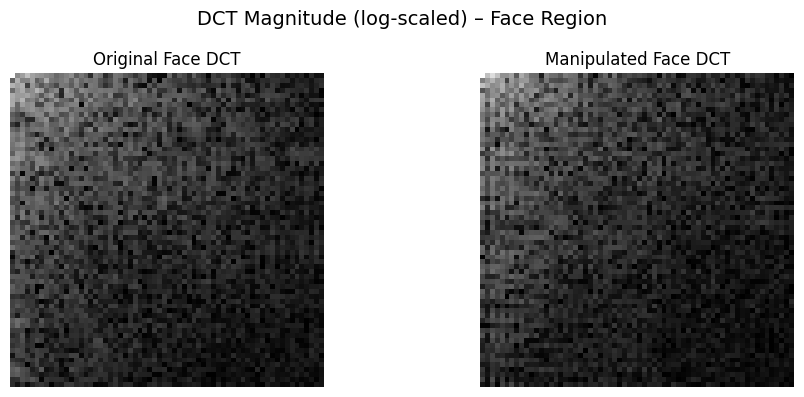

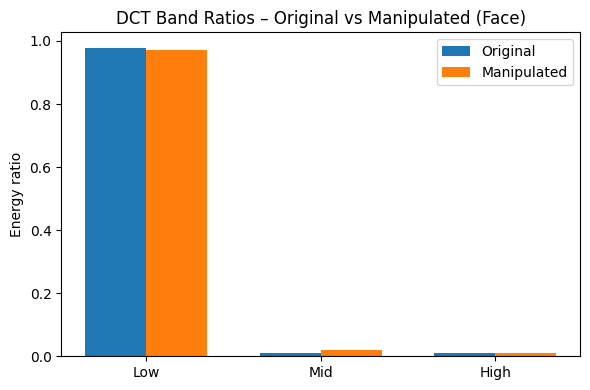

In [37]:
# Compute ratios
orig_low, orig_mid, orig_high = dct_band_ratios(orig_gray)
manip_low, manip_mid, manip_high = dct_band_ratios(manip_gray)

print("Original DCT band ratios:", orig_low, orig_mid, orig_high)
print("Manipulated DCT band ratios:", manip_low, manip_mid, manip_high)

# For visualising DCT magnitude (log scale)
def dct_log_vis(gray):
    small = cv2.resize(gray, (64, 64), interpolation=cv2.INTER_AREA).astype(np.float32)
    d = cv2.dct(small)
    mag = np.log1p(np.abs(d))  # log(1+|d|)
    mag = mag / (mag.max() + 1e-8)
    return mag

orig_dct_vis = dct_log_vis(orig_gray)
manip_dct_vis = dct_log_vis(manip_gray)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("DCT Magnitude (log-scaled) – Face Region", fontsize=14)

axes[0].imshow(orig_dct_vis, cmap="gray")
axes[0].set_title("Original Face DCT")
axes[0].axis("off")

axes[1].imshow(manip_dct_vis, cmap="gray")
axes[1].set_title("Manipulated Face DCT")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Bar chart (grouped) of band ratios
bands = ["Low", "Mid", "High"]
orig_vals = [orig_low, orig_mid, orig_high]
manip_vals = [manip_low, manip_mid, manip_high]

x = np.arange(len(bands))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, orig_vals,  width, label="Original")
plt.bar(x + width/2, manip_vals, width, label="Manipulated")
plt.xticks(x, bands)
plt.ylabel("Energy ratio")
plt.title("DCT Band Ratios – Original vs Manipulated (Face)")
plt.legend()
plt.tight_layout()
plt.show()

### 2.5. JPEG-style blockiness

In [38]:
def jpeg_blockiness(gray):
    gray_f = gray.astype(np.float32)
    h, w = gray.shape

    # vertical boundaries at multiples of 8
    boundary_cols = np.arange(8, w, 8)
    nonboundary_cols = np.setdiff1d(np.arange(1, w), boundary_cols)

    if len(boundary_cols) == 0 or len(nonboundary_cols) == 0:
        return 0.0

    # differences across vertical boundaries
    vert_boundary_diffs = []
    for c in boundary_cols:
        vert_boundary_diffs.append(np.abs(gray_f[:, c] - gray_f[:, c-1]))
    vert_boundary_diffs = np.concatenate(vert_boundary_diffs)

    # differences on non-boundary vertical neighbours
    vert_nonboundary_diffs = []
    for c in nonboundary_cols:
        vert_nonboundary_diffs.append(np.abs(gray_f[:, c] - gray_f[:, c-1]))
    vert_nonboundary_diffs = np.concatenate(vert_nonboundary_diffs)

    vb = vert_boundary_diffs.mean()
    vn = vert_nonboundary_diffs.mean()

    # same for horizontal
    boundary_rows = np.arange(8, h, 8)
    nonboundary_rows = np.setdiff1d(np.arange(1, h), boundary_rows)

    if len(boundary_rows) == 0 or len(nonboundary_rows) == 0:
        return float(vb - vn)

    horiz_boundary_diffs = []
    for r in boundary_rows:
        horiz_boundary_diffs.append(np.abs(gray_f[r, :] - gray_f[r-1, :]))
    horiz_boundary_diffs = np.concatenate(horiz_boundary_diffs)

    horiz_nonboundary_diffs = []
    for r in nonboundary_rows:
        horiz_nonboundary_diffs.append(np.abs(gray_f[r, :] - gray_f[r-1, :]))
    horiz_nonboundary_diffs = np.concatenate(horiz_nonboundary_diffs)

    hb = horiz_boundary_diffs.mean()
    hn = horiz_nonboundary_diffs.mean()

    blockiness_score = (vb - vn + hb - hn) / 2.0
    return float(blockiness_score)

JPEG blockiness – original: 0.057219505310058594
JPEG blockiness – manipulated: -0.04223775863647461


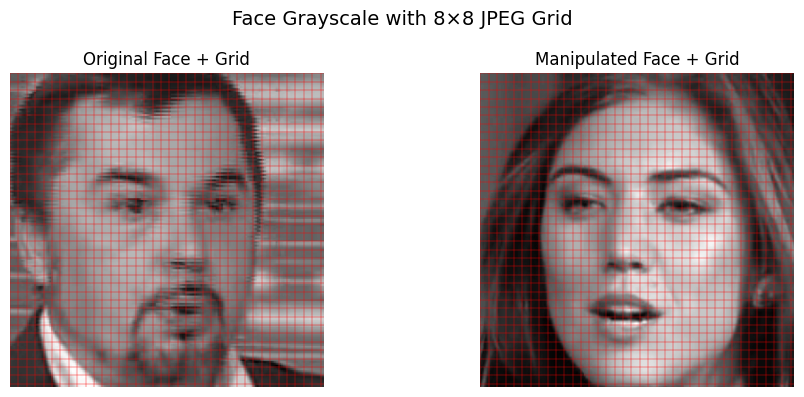

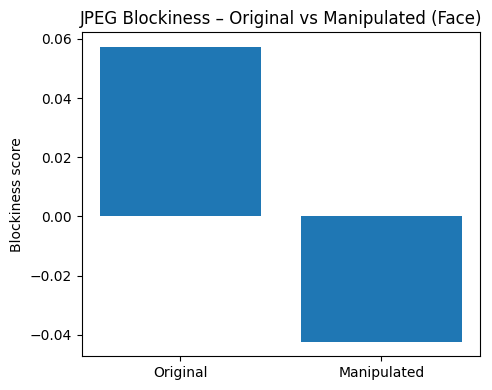

In [39]:
orig_block = jpeg_blockiness(orig_gray)
manip_block = jpeg_blockiness(manip_gray)

print("JPEG blockiness – original:", orig_block)
print("JPEG blockiness – manipulated:", manip_block)

def show_grid(ax, gray, step=8):
    h, w = gray.shape
    ax.imshow(gray, cmap="gray")
    # vertical lines
    for c in range(0, w, step):
        ax.axvline(c - 0.5, color="red", linewidth=0.3)
    # horizontal lines
    for r in range(0, h, step):
        ax.axhline(r - 0.5, color="red", linewidth=0.3)
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Face Grayscale with 8×8 JPEG Grid", fontsize=14)

axes[0].set_title("Original Face + Grid")
show_grid(axes[0], orig_gray)

axes[1].set_title("Manipulated Face + Grid")
show_grid(axes[1], manip_gray)

plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.bar(["Original", "Manipulated"], [orig_block, manip_block])
plt.ylabel("Blockiness score")
plt.title("JPEG Blockiness – Original vs Manipulated (Face)")
plt.tight_layout()
plt.show()


### 2.6. Ring–centre sharpness & Brightness / Chroma differences

In [40]:
def ring_center_features(img_rgb):
    """
    img_rgb: float [0,1], shape (H,W,3) – assumed to be FACE CROP
    Returns: sharp_diff, bright_diff, chroma_diff
    """
    H, W, _ = img_rgb.shape
    gray = get_gray(img_rgb)

    # centre box: middle 40% of face crop
    r1, r2 = int(0.3 * H), int(0.7 * H)
    c1, c2 = int(0.3 * W), int(0.7 * W)

    center_mask = np.zeros((H, W), dtype=bool)
    center_mask[r1:r2, c1:c2] = True
    ring_mask = ~center_mask  # everything else within face crop

    # sharpness via Laplacian variance
    lap = cv2.Laplacian(gray.astype(np.float32), cv2.CV_32F, ksize=3)
    center_sharp = float(lap[center_mask].var())
    ring_sharp   = float(lap[ring_mask].var())
    sharp_diff   = ring_sharp - center_sharp

    # brightness + chroma via HSV
    img_255 = (img_rgb * 255).astype(np.uint8)
    hsv = cv2.cvtColor(img_255, cv2.COLOR_RGB2HSV)
    Hc, Sc, Vc = hsv[..., 0], hsv[..., 1], hsv[..., 2]

    center_brightness = float(Vc[center_mask].mean())
    ring_brightness   = float(Vc[ring_mask].mean())
    bright_diff       = ring_brightness - center_brightness

    center_chroma = float(Sc[center_mask].mean())
    ring_chroma   = float(Sc[ring_mask].mean())
    chroma_diff   = ring_chroma - center_chroma

    return sharp_diff, bright_diff, chroma_diff

Original ring-centre (sharp, bright, chroma): -1106.710693359375 -18.673515526274457 0.1335468415976635
Manipulated ring-centre (sharp, bright, chroma): -56.39362335205078 -53.56804824546782 -3.664316203561725


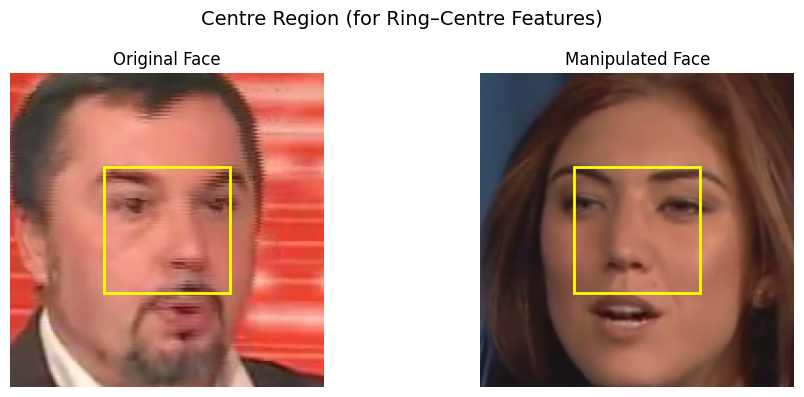

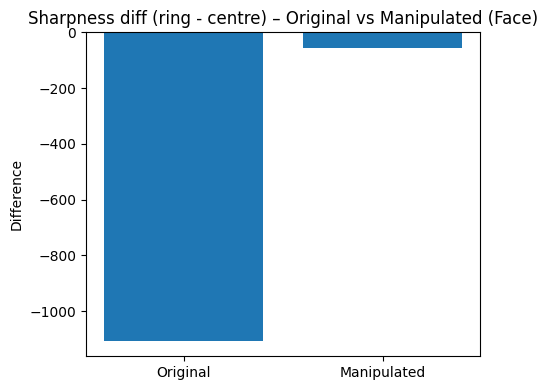

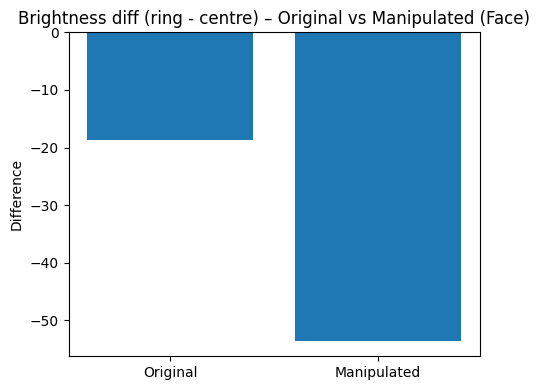

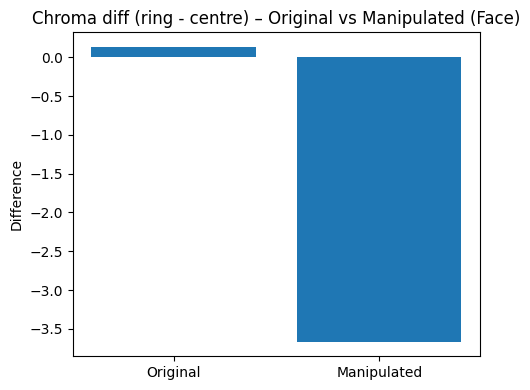

In [41]:
orig_sharp, orig_bright, orig_chroma = ring_center_features(orig_img)
manip_sharp, manip_bright, manip_chroma = ring_center_features(manip_img)

print("Original ring-centre (sharp, bright, chroma):",
      orig_sharp, orig_bright, orig_chroma)
print("Manipulated ring-centre (sharp, bright, chroma):",
      manip_sharp, manip_bright, manip_chroma)

def show_center_box(img_rgb, center_ratio=0.4, ax=None, title=""):
    if ax is None:
        ax = plt.gca()
    H, W, _ = img_rgb.shape
    r1, r2 = int(0.3 * H), int(0.7 * H)
    c1, c2 = int(0.3 * W), int(0.7 * W)

    ax.imshow(img_rgb)
    # rectangle: [x, y, width, height]
    rect = plt.Rectangle((c1, r1), c2 - c1, r2 - r1,
                         edgecolor="yellow", linewidth=2, fill=False)
    ax.add_patch(rect)
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Centre Region (for Ring–Centre Features)", fontsize=14)

show_center_box(orig_img, ax=axes[0], title="Original Face")
show_center_box(manip_img, ax=axes[1], title="Manipulated Face")

plt.tight_layout()
plt.show()

# Separate bar charts for each metric
metrics = ["Sharpness diff (ring - centre)",
           "Brightness diff (ring - centre)",
           "Chroma diff (ring - centre)"]
orig_vals = [orig_sharp, orig_bright, orig_chroma]
manip_vals = [manip_sharp, manip_bright, manip_chroma]

for m, o, f in zip(metrics, orig_vals, manip_vals):
    plt.figure(figsize=(5, 4))
    plt.bar(["Original", "Manipulated"], [o, f])
    plt.ylabel("Difference")
    plt.title(m + " – Original vs Manipulated (Face)")
    plt.tight_layout()
    plt.show()

### 2.7. Feature Extraction

In [42]:
def extract_features_from_image(img_rgb):
    """
    Returns a 1D feature vector for ONE FACE image (RGB [0,1]).
    """
    gray = get_gray(img_rgb)

    hpf_mean, hpf_var     = hpf_features(gray)
    edge_density          = edge_density_canny(gray)
    grad_energy           = gradient_energy(gray)
    lbp_uniform           = lbp_uniformity(gray)
    dct_low, dct_mid, dct_high = dct_band_ratios(gray)
    blockiness            = jpeg_blockiness(gray)
    sharp_diff, bright_diff, chroma_diff = ring_center_features(img_rgb)

    feats = np.array([
        hpf_mean,
        hpf_var,
        edge_density,
        grad_energy,
        lbp_uniform,
        dct_low,
        dct_mid,
        dct_high,
        blockiness,
        sharp_diff,
        bright_diff,
        chroma_diff
    ], dtype=np.float32)

    return feats

## 3. Classical Model Training
We:

1. Split into train / validation / test.
2. Extract 12 handcrafted features per image (face-cropped, 299×299).
3. Train Logistic Regression, Random Forest, and XGBoost baselines.

### 3.1. Dataset Preparation

In [ ]:
RANDOM_SEED = 42

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=RANDOM_SEED
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=RANDOM_SEED
)

print(len(train_df), len(val_df), len(test_df))

7000 1500 1500


In [44]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def _extract_single(args):
    full_path, label = args
    try:
        img = load_image_rgb(full_path)
        feats = extract_features_from_image(img)
        return feats, label, None
    except Exception as e:
        return None, None, (full_path, str(e))


def extract_feature_batch_parallel(df, max_images=None, num_workers=None):
    if num_workers is None:
        num_workers = os.cpu_count() or 4

    paths = df["path"].tolist()
    labels = df["label"].tolist()

    if max_images:
        paths = paths[:max_images]
        labels = labels[:max_images]

    tasks = [(os.path.join(p), y) for p, y in zip(paths, labels)]

    X_list = []
    y_list = []
    errors = []

    print(f"Starting parallel extraction on {len(tasks)} images with {num_workers} workers")

    with ThreadPoolExecutor(max_workers=num_workers) as ex:
        futures = [ex.submit(_extract_single, t) for t in tasks]
        for i, fut in enumerate(as_completed(futures), start=1):
            feats, label, err = fut.result()
            if err is not None:
                path, msg = err
                print(f"Error: {path} -> {msg}")
                errors.append(err)
                continue

            X_list.append(feats)
            y_list.append(label)

            if i % 500 == 0:
                print(f"Processed {i}/{len(tasks)} images")

    X = np.vstack(X_list)
    y = np.array(y_list)

    print(f"Done. Successful: {len(y_list)}, errors: {len(errors)}")
    return X, y


In [45]:
X_train, y_train = extract_feature_batch_parallel(train_df)
print("Train features shape:", X_train.shape)

X_val, y_val = extract_feature_batch_parallel(val_df)
print("Val features shape:", X_val.shape)

X_test, y_test = extract_feature_batch_parallel(test_df)
print("Test features shape:", X_test.shape)

Starting parallel extraction on 7000 images with 12 workers
Processed 500/7000 images
Processed 1000/7000 images
Processed 1500/7000 images
Processed 2000/7000 images
Processed 2500/7000 images
Processed 3000/7000 images
Processed 3500/7000 images
Processed 4000/7000 images
Processed 4500/7000 images
Processed 5000/7000 images
Processed 5500/7000 images
Processed 6000/7000 images
Processed 6500/7000 images
Processed 7000/7000 images
Done. Successful: 7000, errors: 0
Train features shape: (7000, 12)
Starting parallel extraction on 1500 images with 12 workers
Processed 500/1500 images
Processed 1000/1500 images
Processed 1500/1500 images
Done. Successful: 1500, errors: 0
Val features shape: (1500, 12)
Starting parallel extraction on 1500 images with 12 workers
Processed 500/1500 images
Processed 1000/1500 images
Processed 1500/1500 images
Done. Successful: 1500, errors: 0
Test features shape: (1500, 12)


In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)


In [47]:
# Save a mapping from path -> feature vector for later (ResNet50 Fusion)
train_feat_dict = {
    row["path"]: X_train[i]
    for i, row in train_df.reset_index(drop=True).iterrows()
}

val_feat_dict = {
    row["path"]: X_val[i]
    for i, row in val_df.reset_index(drop=True).iterrows()
}

test_feat_dict = {
    row["path"]: X_test[i]
    for i, row in test_df.reset_index(drop=True).iterrows()
}


### 3.2. Logistic Regression

In [48]:
lr = LogisticRegression(max_iter=500, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict_proba(X_val_scaled)[:, 1]
print("LR Validation AUC:", roc_auc_score(y_val, pred_lr))


LR Validation AUC: 0.6077795555555555


/Users/siruitan/Documents/NUS BZA/Y4S1/BT4012/BT4012/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/siruitan/Documents/NUS BZA/Y4S1/BT4012/BT4012/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/siruitan/Documents/NUS BZA/Y4S1/BT4012/BT4012/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/siruitan/Documents/NUS BZA/Y4S1/BT4012/BT4012/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/siruitan/Documents/NUS BZA/Y4S1/BT4012/BT4012/lib/python3.12/site-packages/sklearn/linear_mo

### 3.3. Random Forest

Random Forest Validation AUC: 0.6731626666666667


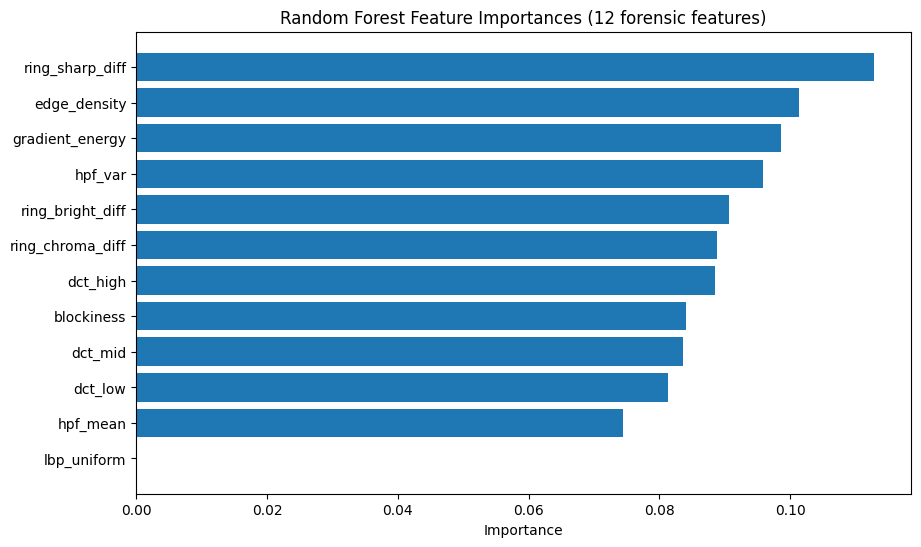

In [49]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train, y_train)
pred_rf = rf.predict_proba(X_val)[:, 1]

print("Random Forest Validation AUC:", roc_auc_score(y_val, pred_rf))

feature_names = [
    "hpf_mean", "hpf_var",
    "edge_density", "gradient_energy",
    "lbp_uniform",
    "dct_low", "dct_mid", "dct_high",
    "blockiness",
    "ring_sharp_diff", "ring_bright_diff", "ring_chroma_diff",
]

importances = rf.feature_importances_
idx_sorted = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(np.array(feature_names)[idx_sorted], importances[idx_sorted])
plt.title("Random Forest Feature Importances (12 forensic features)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


### 3.4. XGBoost

In [50]:
num_negatives = (y_train == 0).sum()
num_positives = (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=num_negatives / num_positives,
    random_state=42,
)

xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict_proba(X_val)[:, 1]

print("XGBoost Validation AUC:", roc_auc_score(y_val, pred_xgb))


XGBoost Validation AUC: 0.6607342222222222


### 3.5 Evaluation Metrics

Logistic Regression AUC: 0.6078, Accuracy: 0.5913


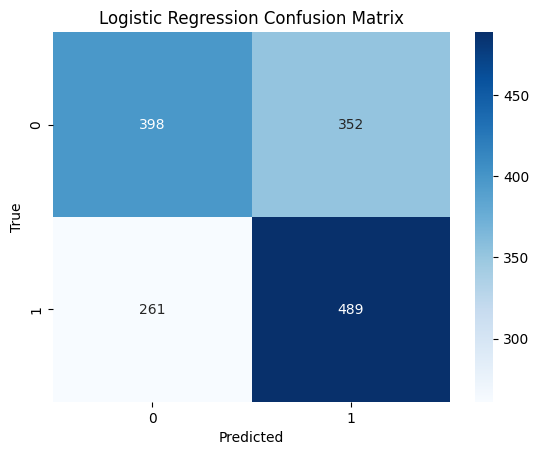

Random Forest AUC: 0.6732, Accuracy: 0.6387


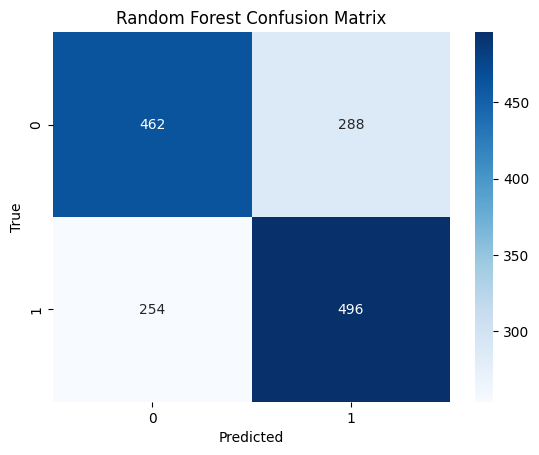

XGBoost AUC: 0.6607, Accuracy: 0.6093


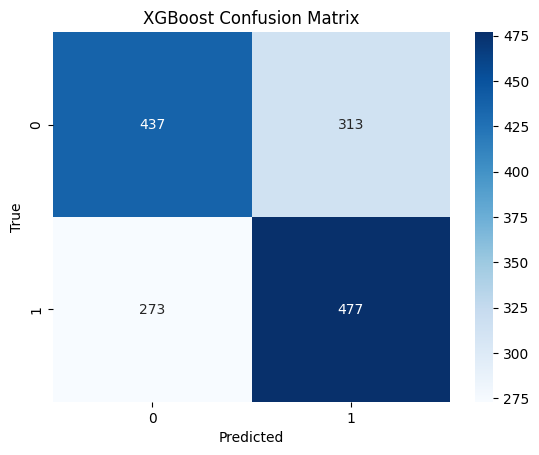

In [51]:
def evaluate_model(name, y_true, y_pred_prob, threshold=0.5):
    auc = roc_auc_score(y_true, y_pred_prob)
    y_pred = (y_pred_prob > threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    print(f"{name} AUC: {auc:.4f}, Accuracy: {acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

evaluate_model("Logistic Regression", y_val, pred_lr)
evaluate_model("Random Forest",      y_val, pred_rf)
evaluate_model("XGBoost",            y_val, pred_xgb)


## 4. CNN: ResNet50 Fusion

### 4.1. Dataset Preparation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
cv2.ocl.setUseOpenCL(False)


class DeepfakeImageDataset(Dataset):
    def __init__(self, df_in):
        self.paths = df_in["path"].tolist()
        self.labels = df_in["label"].astype(int).tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        # --- load + preprocess image ---
        img_bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise ValueError(f"Could not read image: {path}")

        # === Face-centered crop OR fallback ===
        face_bgr = crop_to_face_or_center(img_bgr)

        img_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, IMG_SIZE, interpolation=cv2.INTER_AREA)
        img_rgb = img_rgb.astype(np.float32) / 255.0  # [H,W,3] in [0,1]

        # --- handcrafted features ---
        feats = extract_features_from_image(img_rgb)  # np.array (F,)

        # --- convert to tensors (no torch.from_numpy) ---
        img_chw = img_rgb.transpose(2, 0, 1)          # (3,H,W)
        img_tensor = torch.tensor(img_chw, dtype=torch.float32)
        feat_tensor = torch.tensor(feats, dtype=torch.float32)
        label_tensor = torch.tensor(label, dtype=torch.float32)  # scalar 0/1

        return img_tensor, feat_tensor, label_tensor

train_dataset_img = DeepfakeImageDataset(train_df)
val_dataset_img   = DeepfakeImageDataset(val_df)
test_dataset_img  = DeepfakeImageDataset(test_df)

BATCH_SIZE_IMG = 64

train_loader_img = DataLoader(
    train_dataset_img,
    batch_size=BATCH_SIZE_IMG,
    shuffle=True,
    num_workers= os.cpu_count() or 4,
    pin_memory=True,
    drop_last=True
)

val_loader_img = DataLoader(
    val_dataset_img,
    batch_size=BATCH_SIZE_IMG,
    shuffle=False,
    num_workers= os.cpu_count() or 4,
    pin_memory=True,
    drop_last=True
)

test_loader_img = DataLoader(
    test_dataset_img,
    batch_size=BATCH_SIZE_IMG,
    shuffle=False,
    num_workers= os.cpu_count() or 4,
    pin_memory=True,
    drop_last=True
)

print("Train batches:", len(train_loader_img), " | Val batches:", len(val_loader_img))


Using device: cuda
Train batches: 109  | Val batches: 23


In [ ]:
w_neg = num_positives / (num_positives + num_negatives)
w_pos = num_negatives / (num_positives + num_negatives)
print("Class weights -> w_neg (for label 0):", w_neg, ", w_pos (for label 1):", w_pos)

w_neg_t = torch.tensor(w_neg, device=device)
w_pos_t = torch.tensor(w_pos, device=device)

Class weights -> w_neg (for label 0): 0.5 , w_pos (for label 1): 0.5


In [ ]:
for i in train_loader_img:
    print(i[0].shape, i[1].shape, i[2].shape)
    break

torch.Size([64, 3, 299, 299]) torch.Size([64, 12]) torch.Size([64])


In [ ]:
print(train_df['method'].value_counts())
print(val_df['method'].value_counts())
print(test_df['method'].value_counts())

method
youtube           3500
FaceShifter        718
NeuralTextures     711
FaceSwap           703
Deepfakes          686
Face2Face          682
Name: count, dtype: int64
method
youtube           750
Deepfakes         162
Face2Face         160
FaceSwap          154
NeuralTextures    144
FaceShifter       130
Name: count, dtype: int64
method
youtube           750
Face2Face         158
FaceShifter       152
Deepfakes         152
NeuralTextures    145
FaceSwap          143
Name: count, dtype: int64


### Fusion ResNet Model

In [ ]:
class DeepfakeResNet50(nn.Module):
    def __init__(self, feat_dim, hidden_dim=256):
        super().__init__()

        # -----------------------------------------
        # 1. Load pretrained backbone
        # -----------------------------------------
        self.backbone = tv_models.resnet50(
            weights=tv_models.ResNet50_Weights.IMAGENET1K_V2
        )

        # -----------------------------------------
        # 2. Freeze early layers to prevent overfitting
        # Train ONLY layer4 and the new classifier
        # -----------------------------------------
        for name, param in self.backbone.named_parameters():
            if not name.startswith("layer4"):
                param.requires_grad = False

        # Replace final FC with identity
        self.backbone.fc = nn.Identity()

        # CNN output dim (2048 from ResNet50) + handcrafted feat_dim
        input_dim = 2048 + feat_dim

        # -----------------------------------------
        # 3. Add BatchNorm after concatenation
        # -----------------------------------------
        self.norm = nn.BatchNorm1d(input_dim)

        # -----------------------------------------
        # 4. Improved classifier (two hidden layers)
        # -----------------------------------------
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(hidden_dim // 2, 1),
            # (No sigmoid, since loss = BCEWithLogitsLoss)
        )

    def forward(self, img, feats):
        # Extract CNN features
        img_feats = self.backbone(img)  # (B, 2048)

        # Concatenate CNN & handcrafted features
        x = torch.cat([img_feats, feats], dim=1)

        # Normalize merged features
        x = self.norm(x)

        # Pass through classifier
        logits = self.classifier(x)
        return logits.squeeze(1)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc="Training", leave=False)

    for img, feats, labels in pbar:
        img = img.to(device)
        feats = feats.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(img, feats)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=False)
        for img, feats, labels in pbar:
            img = img.to(device)
            feats = feats.to(device)
            labels = labels.to(device)

            logits = model(img, feats)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            # Convert logits -> prediction
            preds = (torch.sigmoid(logits) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return total_loss / len(loader), accuracy

In [ ]:
EPOCHS = 10
criterion = nn.BCEWithLogitsLoss(
    # pos_weight=w_pos_t / w_neg_t  # ratio balances classes
)
# get one batch
feat_dim = 0

for img, feats, labels in train_loader_img:
    feat_dim = feats.shape[1]
    break

print(feat_dim)
model = DeepfakeResNet50(feat_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


for epoch in range(EPOCHS):
    print(epoch)
    train_loss = train_one_epoch(model, train_loader_img, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader_img, criterion, device)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")

12
0


Epoch 01 | Train Loss: 0.6305 | Val Loss: 0.5208 | Val Acc: 0.7391
1


Epoch 02 | Train Loss: 0.3530 | Val Loss: 0.5411 | Val Acc: 0.7493
2


Epoch 03 | Train Loss: 0.1032 | Val Loss: 0.5365 | Val Acc: 0.8030
3


Epoch 04 | Train Loss: 0.0494 | Val Loss: 0.7301 | Val Acc: 0.7833
4


...

Epoch 06 | Train Loss: 0.0334 | Val Loss: 0.7266 | Val Acc: 0.7948
6


Epoch 07 | Train Loss: 0.0285 | Val Loss: 0.8259 | Val Acc: 0.7812
7


Epoch 08 | Train Loss: 0.0281 | Val Loss: 0.7723 | Val Acc: 0.7996
8


Epoch 09 | Train Loss: 0.0215 | Val Loss: 0.8925 | Val Acc: 0.7928
9


Epoch 10 | Train Loss: 0.0262 | Val Loss: 0.7318 | Val Acc: 0.8139


In [ ]:
torch.save(model.state_dict(), "deepfake_resnet50.pth")

### 4.3. Evaluation Metrics

In [ ]:
model = DeepfakeResNet50(feat_dim)
model.load_state_dict(torch.load("deepfake_resnet50.pth"))
model.to(device)
model.eval()

DeepfakeResNet50(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(


Testing: 100%|██████████| 23/23 [01:12<00:00,  3.14s/it]



=== Confusion Matrix ===
[[635 104]
 [165 568]]

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.7937    0.8593    0.8252       739
           1     0.8452    0.7749    0.8085       733

    accuracy                         0.8173      1472
   macro avg     0.8195    0.8171    0.8169      1472
weighted avg     0.8194    0.8173    0.8169      1472


ROC-AUC: 0.9026


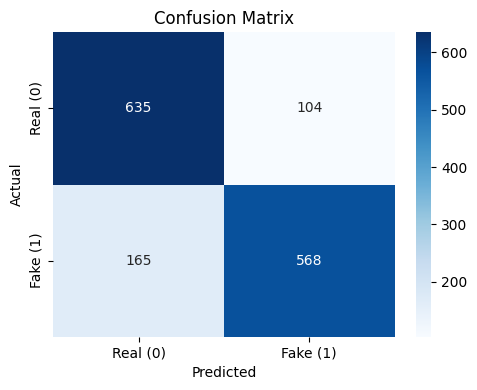

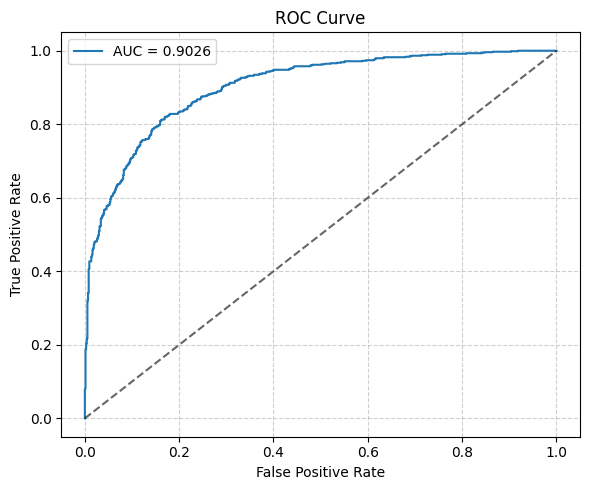

In [ ]:
import numpy as np
import torch
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------
# Predict on test dataset
# --------------------------
def evaluate_on_test(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for img, feats, labels in tqdm(loader, desc="Testing"):
            img = img.to(device)
            feats = feats.to(device)
            labels = labels.to(device)

            logits = model(img, feats)
            probs = torch.sigmoid(logits)

            preds = (probs > 0.5).long()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels).astype(int)
    all_preds = np.array(all_preds).astype(int)
    all_probs = np.array(all_probs).astype(float)

    return all_labels, all_preds, all_probs


# Run evaluation
y_true, y_pred, y_prob = evaluate_on_test(model, test_loader_img, device)

# --------------------------
# Metrics
# --------------------------
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_true, y_pred)
print(cm)

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, digits=4))

auc = roc_auc_score(y_true, y_prob)
print(f"\nROC-AUC: {auc:.4f}")

# --------------------------
# Plot Confusion Matrix Heatmap
# --------------------------
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real (0)", "Fake (1)"],
            yticklabels=["Real (0)", "Fake (1)"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# --------------------------
# Plot ROC Curve
# --------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## 5. CNN: Xception

### 5.1. Dataset Preparation

In [ ]:
class DeepfakeSequence(Sequence):
    def __init__(self, df_in, batch_size=32, shuffle=True, augment=False):
        self.paths = df_in["path"].tolist()
        self.labels = df_in["label"].astype(float).tolist()
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _augment_np(self, img):
        # img: float [0,1], HWC
        # simple augmentations similar-ish to your ImageDataGenerator
        if np.random.rand() < 0.5:
            img = np.fliplr(img)

        # small brightness jitter
        if np.random.rand() < 0.5:
            factor = np.random.uniform(0.8, 1.2)
            img = np.clip(img * factor, 0.0, 1.0)

        return img

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_paths = [self.paths[i] for i in batch_idx]
        batch_labels = [self.labels[i] for i in batch_idx]

        batch_x = []
        for p in batch_paths:
            img_rgb = load_image_rgb(p)  # [0,1]
            if self.augment:
                img_rgb = self._augment_np(img_rgb)
            img_255 = img_rgb * 255.0
            img_pre = preprocess_input(img_255)
            batch_x.append(img_pre)

        batch_x = np.stack(batch_x, axis=0).astype(np.float32)
        batch_y = np.array(batch_labels, dtype=np.float32)
        return batch_x, batch_y


In [ ]:
BATCH_SIZE_XCP = 32

train_gen_xcp = DeepfakeSequence(train_df, batch_size=BATCH_SIZE_XCP, shuffle=True,  augment=True)
val_gen_xcp   = DeepfakeSequence(val_df,   batch_size=BATCH_SIZE_XCP, shuffle=False, augment=False)
test_gen_xcp  = DeepfakeSequence(test_df,  batch_size=BATCH_SIZE_XCP, shuffle=False, augment=False)


In [ ]:
IMG_SIZE = (299, 299)  # ensure consistent with loader

inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# NOTE: data is already preprocessed by preprocess_input in Sequence
x = inputs

base_model_xcp = Xception(
    weights="imagenet",
    include_top=False,
    pooling="avg",
)

base_model_xcp.trainable = False  # frozen for initial training

x = base_model_xcp(x, training=False)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

xception_model = keras_models.Model(inputs, outputs)

xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="AUC")],
)

xception_model.summary()


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,911,081 (83.58 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
checkpoint_path = "xception_best_val_auc.weights.h5"

callbacks_xcp = [
    EarlyStopping(
        monitor="val_AUC",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_AUC",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_AUC",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

num_negatives_total = (df["label"] == 0).sum()
num_positives_total = (df["label"] == 1).sum()
total_all = num_negatives_total + num_positives_total

class_weights_tf = {
    0: total_all / (2 * num_negatives_total),
    1: total_all / (2 * num_positives_total),
}

class_weights_tf


{0: np.float64(3.4606749816581073), 1: np.float64(0.5844402041928929)}

In [ ]:
EPOCHS_XCP = 10

history_xcp = xception_model.fit(
    train_gen_xcp,
    validation_data=val_gen_xcp,
    epochs=EPOCHS_XCP,
    callbacks=callbacks_xcp,
    class_weight=class_weights_tf,
)

xception_model.load_weights(checkpoint_path)

# Validation
val_probs_xcp = xception_model.predict(val_gen_xcp).ravel()
y_val_true_xcp = val_df["label"].values

val_auc_xcp = roc_auc_score(y_val_true_xcp, val_probs_xcp)
val_acc_xcp = accuracy_score(y_val_true_xcp, (val_probs_xcp > 0.5).astype(int))

print(f"Xception (frozen) Val AUC: {val_auc_xcp:.4f}, Accuracy: {val_acc_xcp:.4f}")

# Test
test_probs_xcp = xception_model.predict(test_gen_xcp).ravel()
y_test_true_xcp = test_df["label"].values

test_auc_xcp = roc_auc_score(y_test_true_xcp, test_probs_xcp)
test_acc_xcp = accuracy_score(y_test_true_xcp, (test_probs_xcp > 0.5).astype(int))

print(f"Xception (frozen) Test AUC: {test_auc_xcp:.4f}, Accuracy: {test_acc_xcp:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - AUC: 0.2409 - accuracy: 0.5547 - loss: 0.6803
Epoch 1: val_AUC improved from -inf to 0.59615, saving model to xception_best_val_auc.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 100s 31s/step - AUC: 0.2503 - accuracy: 0.5768 - loss: 0.7505 - val_AUC: 0.5962 - val_accuracy: 0.8667 - val_loss: 0.4157 - learning_rate: 3.0000e-04
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27s/step - AUC: 0.8167 - accuracy: 0.8530 - loss: 0.6936 
Epoch 2: val_AUC improved from 0.59615 to 0.65385, saving model to xception_best_val_auc.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 79s 34s/step - AUC: 0.7880 - accuracy: 0.8540 - loss: 0.7034 - val_AUC: 0.6538 - val_accuracy: 0.8667 - val_loss: 0.5144 - learning_rate: 3.0000e-04
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - AUC: 0.7898 - accuracy: 0.7836 - loss: 0.6309  
Epoch 3: val_AUC did not improve from 0.65385
3/3 ━━━━━━━━━━━━━━━━━━━━ 74s 16s/step - AUC: 0.7736 - accuracy: 0.7770 - loss: 0.6343 - val_AUC: 0.5385 - val_accuracy

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Xception (frozen) Test AUC: 0.3846, Accuracy: 0.8667


In [ ]:
for layer in base_model_xcp.layers:
    layer.trainable = True

xception_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="AUC")],
)
xception_model.summary()

history_xcp_ft = xception_model.fit(
    train_gen_xcp,
    validation_data=val_gen_xcp,
    epochs=10,
    callbacks=callbacks_xcp,
    class_weight=class_weights_tf,
)

# Re-evaluate
val_probs_xcp_ft = xception_model.predict(val_gen_xcp).ravel()
val_auc_xcp_ft = roc_auc_score(y_val_true_xcp, val_probs_xcp_ft)
val_acc_xcp_ft = accuracy_score(y_val_true_xcp, (val_probs_xcp_ft > 0.5).astype(int))
print(f"Xception (finetuned) Val AUC: {val_auc_xcp_ft:.4f}, Accuracy: {val_acc_xcp_ft:.4f}")

test_probs_xcp_ft = xception_model.predict(test_gen_xcp).ravel()
test_auc_xcp_ft = roc_auc_score(y_test_true_xcp, test_probs_xcp_ft)
test_acc_xcp_ft = accuracy_score(y_test_true_xcp, (test_probs_xcp_ft > 0.5).astype(int))
print(f"Xception (finetuned) Test AUC: {test_auc_xcp_ft:.4f}, Accuracy: {test_acc_xcp_ft:.4f}")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,911,081 (83.58 MB)

 Trainable params: 21,856,553 (83.38 MB)

 Non-trainable params: 54,528 (213.00 KB)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37s/step - AUC: 0.5453 - accuracy: 0.8482 - loss: 0.8144  
Epoch 1: val_AUC improved from 0.65385 to 0.69231, saving model to xception_best_val_auc.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 261s 52s/step - AUC: 0.5450 - accuracy: 0.8504 - loss: 0.8043 - val_AUC: 0.6923 - val_accuracy: 0.8667 - val_loss: 0.5181 - learning_rate: 1.0000e-05
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71s/step - AUC: 0.8023 - accuracy: 0.7974 - loss: 0.8713  
Epoch 2: val_AUC did not improve from 0.69231
3/3 ━━━━━━━━━━━━━━━━━━━━ 184s 82s/step - AUC: 0.7941 - accuracy: 0.8123 - loss: 0.8254 - val_AUC: 0.6923 - val_accuracy: 0.8667 - val_loss: 0.5197 - learning_rate: 1.0000e-05
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39s/step - AUC: 0.6563 - accuracy: 0.8487 - loss: 0.6850  
Epoch 3: val_AUC did not improve from 0.69231
3/3 ━━━━━━━━━━━━━━━━━━━━ 179s 45s/step - AUC: 0.6631 - accuracy: 0.8472 - loss: 0.6940 - val_AUC: 0.6923 - val_accuracy: 0.8667 - val_loss: 0.5219 - learning_rate: 